# K562 H3K27ac Enhancer Activity Prediction Pipeline

**Full implementation of the canonical GFM workflow from Lecture 4.**

This notebook implements the steps given in the lecture workflow using the running example:
predicting enhancer activity (H3K27ac signal) in K562 cells from 1 kb DNA sequences.


| Step | Section | What’s Implemented |
|:---:|---|---|
| **0** | Define biological question | Input/Output/Resolution specification |
| **1** | Model selection | Nucleotide Transformer + CNN baseline |
| **2** | Fine-tuning strategy | Frozen → partial unfreeze (staged) |
| **3** | Data curation & splits | Chromosome-aware splits  |
| **4** | Tokenization | NT native tokenizer + one-hot for CNN |
| **5** | Preprocessing | Log-transform signal, length normalization |
| **6** | Experimental setup | MSE loss, Pearson/Spearman/RMSE metrics |
| **7** | Fine-tuning | Stage 1 (frozen) → Stage 2 (top layers) + CNN baseline |
| **8** | Evaluation & interpretation | Per-chromosome metrics, model comparison, saliency maps |


## 🧬 The Use Case: Predicting Enhancer Activity from DNA Sequence

### What are we trying to solve?

**Biological Context:**  
Enhancers are non-coding DNA regions that regulate gene expression. In K562 cells (a human leukemia cell line), active enhancers are marked by **H3K27ac** — a histone modification detectable through ChIP-seq. Predicting enhancer activity directly from DNA sequence would help us:

- Understand regulatory grammar encoded in DNA
- Identify disease-causing mutations in non-coding regions
- Design synthetic enhancers for gene therapy

### Our Task

> **Given:** A 1kb DNA sequence centered on a candidate enhancer  
> **Predict:** The H3K27ac ChIP-seq signal intensity (continuous value)

This is a **sequence-to-value regression problem** — we're learning the mapping from genomic sequence to regulatory activity.

### The Workflow

The diagram below illustrates our end-to-end pipeline from raw genomic data to interpretable predictions:

<img src="../../images/promoter-usecase.svg" width="700" style="display: block; margin: 20px auto;">

**Key Steps:**
1. **Data:** Extract 1kb windows around ChIP-seq peaks
2. **Model:** Fine-tune Nucleotide Transformer for regression
3. **Training:** Staged approach (frozen → partial unfreeze)
4. **Evaluation:** Compare to CNN baseline, analyze per-chromosome performance
5. **Interpretation:** Use saliency maps to identify important sequence features

---

### Why This Matters

This notebook demonstrates the **complete canonical workflow** from Lecture 4:
- How to translate a biological question into a concrete ML task
- Best practices for data splitting, tokenization, and preprocessing
- Proper comparison to baselines (not just other foundation models!)
- Biologically meaningful evaluation and interpretation

Let's dive in! 🚀

In [ ]:
# Visualize the workflow (optional - if SVG image exists)
from IPython.display import SVG, display
from pathlib import Path

svg_path = Path("../../images/promoter-usecase.svg")
if svg_path.exists():
    display(SVG(filename=str(svg_path)))
else:
    print("Note: Workflow diagram not found. See markdown cell above for description.")

## Learning Objectives

> *Mapped from Lecture 4 slide “Learning Objectives”*

After completing this notebook, you should be able to:

1. **Translate** a biological question into a concrete GFM task (Input → Output → Resolution)
2. **Select and justify** a model and baseline, with explicit reasoning
3. **Prepare data** with chromosome-aware splits that avoid leakage
4. **Tokenize and preprocess** sequences aligned with model expectations
5. **Train** using staged fine-tuning (frozen → partial unfreeze)
6. **Evaluate** with biologically meaningful metrics (Pearson, Spearman, per-chromosome)
7. **Interpret** predictions using attribution/saliency analysis


In [ ]:
# === DATA DOWNLOAD & VERIFICATION ===
# Download ENCODE K562 H3K27ac data using the provided script
# This script checks if files exist before downloading to avoid redundant downloads

import subprocess
import os
from pathlib import Path

# Run the download script
data_dir = Path('../../data')
download_script = data_dir / 'download_k562_h3k27ac_files.sh'

if download_script.exists():
    print("Running K562 data download script...")
    print("=" * 60)
    result = subprocess.run(['bash', str(download_script)], 
                          cwd=str(data_dir), 
                          capture_output=True, 
                          text=True)
    print(result.stdout)
    if result.returncode != 0:
        print("Warning:", result.stderr)
    print("=" * 60)
else:
    print(f"Warning: Download script not found at {download_script}")
    print("Please ensure the script exists or download data manually:")
    print("  - K562_H3K27ac.bigWig (ChIP-seq signal)")
    print("  - K562_peaks.bed (called peaks)")  
    print("  - hg38.fa + hg38.fa.fai (reference genome)")

# Verify all required files exist
print("\nVerifying data files...")
required_files = {
    'K562_H3K27ac.bigWig': 'ChIP-seq signal track',
    'K562_peaks.bed': 'Called peaks (enhancer candidates)',
    'hg38.fa': 'Human reference genome',
    'hg38.fa.fai': 'Genome index (for pyfaidx)'
}

all_present = True
for filename, description in required_files.items():
    filepath = data_dir / filename
    if filepath.exists():
        size_mb = filepath.stat().st_size / (1024**2)
        print(f"  ✓ {filename:30s} ({size_mb:>8.1f} MB) - {description}")
    else:
        print(f"  ✗ {filename:30s} MISSING - {description}")
        all_present = False

if all_present:
    print("\n✓ All required data files are present!")
else:
    print("\n⚠ Some data files are missing. Run the download script or download manually.")

In [4]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import pyBigWig
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error, r2_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from captum.attr import IntegratedGradients
from pyfaidx import Fasta
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


Device: cuda


In [15]:
# ============================================================
# CONFIGURATION
# ============================================================
# Set QUICK_MODE = True for workshop demo (~10-15 min total training)
# Set QUICK_MODE = False for full research-grade run (~1-2 hours)
QUICK_MODE = True

# Model
MODEL_NAME = "InstaDeepAI/nucleotide-transformer-500m-human-ref"

# Data sizes (adjusted by QUICK_MODE)
if QUICK_MODE:
    MAX_TRAIN, MAX_VAL, MAX_TEST = 5000, 1000, 2000
    NUM_EPOCHS = 5
    BATCH_SIZE = 32
    print("QUICK_MODE enabled: using data subset for faster training")
else:
    MAX_TRAIN, MAX_VAL, MAX_TEST = None, None, None
    NUM_EPOCHS = 10
    BATCH_SIZE = 32
    print("FULL MODE: using complete dataset")

# Fine-tuning
NUM_UNFREEZE_LAYERS = 2   # Transformer layers to unfreeze in Stage 2
PATIENCE = 3              # Early stopping patience

# Tokenizer
NT_MAX_LENGTH = 256       # Max tokens for NT (1kb seq ~ 170 tokens)


QUICK_MODE enabled: using data subset for faster training


## Step 0 — Define the Biological Question

> *“Before touching code, answer: What is the biological object?*
> *What is the prediction type? What is the resolution?”*

### Our Running Example

| Aspect | Definition |
|--------|-----------|
| **Biological object** | DNA sequence (1 kb windows around candidate enhancers) |
| **Prediction type** | **Regression** — continuous enhancer activity signal |
| **Resolution** | Locus-level, human genome (hg38), single cell type (K562) |
| **Assay** | H3K27ac ChIP-seq (histone mark of active enhancers) |

**Formal task definition:**

> Given a 1 kb DNA sequence centered on a candidate enhancer summit in K562 cells,
> predict the mean H3K27ac signal intensity over that window.

This is a **sequence → continuous value** regression task.


In [6]:
# ============================================================
# Step 0+3: Load raw data and explore
# ============================================================

# Load H3K27ac signal track
bw = pyBigWig.open('../../data/K562_H3K27ac.bigWig')

# Load called peaks (narrowPeak format: 10 columns)
peaks = pd.read_csv('../../data/K562_peaks.bed', sep='\t', header=None, comment='#')
peaks.columns = ['chrom', 'start', 'end', 'name', 'score', 'strand',
                 'signal', 'pval', 'qval', 'peak']

# Center windows on peak SUMMITS (not start)
# Lecture: "1 kb around peak summits (centered or shifted by assay)"
peaks['summit'] = peaks['start'] + peaks['peak']
peaks['win_start'] = peaks['summit'] - 500
peaks['win_end'] = peaks['summit'] + 500

# Filter: keep only standard chromosomes, valid coordinates
valid_chroms = ['chr' + str(i) for i in range(1, 23)] + ['chrX']
peaks = peaks[peaks.chrom.isin(valid_chroms)]
peaks = peaks[peaks.win_start >= 0]

# Extract mean H3K27ac signal over each 1 kb window
peaks['mean_signal'] = peaks.apply(
    lambda r: np.nanmean(bw.values(r.chrom, r.win_start, r.win_end)), axis=1
)
peaks = peaks.dropna(subset=['mean_signal']).query('mean_signal > 0')

# Extract DNA sequences from reference genome
genome = Fasta('../../data/hg38.fa')

def get_seq(chrom, start, end):
    try:
        return str(genome[chrom][start:end]).upper()
    except Exception:
        return None

peaks['sequence'] = peaks.apply(
    lambda r: get_seq(r.chrom, r.win_start, r.win_end), axis=1
)
peaks = peaks.dropna(subset=['sequence'])

# Remove sequences with too many ambiguous bases (>10% N)
peaks = peaks[peaks.sequence.apply(lambda s: s.count('N') / len(s) < 0.1)]

print(f'Total enhancer windows: {len(peaks):,}')
print(f'Signal range: {peaks.mean_signal.min():.2f} – {peaks.mean_signal.max():.2f}')
print(f'Chromosomes: {sorted(peaks.chrom.unique())}')
peaks[['chrom', 'summit', 'mean_signal']].describe()


Total enhancer windows: 52,315
Signal range: 0.00 – 521.64
Chromosomes: ['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrX']


,summit,mean_signal
count,5.231500e+04,52315.000000
mean,7.444441e+07,29.424412
std,5.599337e+07,41.429403
min,2.037500e+04,0.001000
25%,3.131856e+07,5.498675
50%,6.088213e+07,13.263310
75%,1.102270e+08,34.938977
max,2.489265e+08,521.643552


In [7]:
peaks

,chrom,start,end,name,score,strand,signal,pval,qval,peak,summit,win_start,win_end,mean_signal,sequence
0,chr10,100005984,100006425,Peak_28342,22,.,7.96029,13.27658,10.98984,313,100006297,100005797,100006797,9.149550,AGGAAAATGAATTACAGCATTATAAATCAAGATACATACACATAAA...
1,chr10,100184810,100186003,Peak_6112,103,.,27.08250,83.90475,80.68768,858,100185668,100185168,100186168,84.453128,AACTAAAGCCTGTACAGTTGAACGAACTATAATTTATCCATCTCTT...
2,chr10,100186040,100187496,Peak_2833,167,.,43.56135,139.43907,135.76637,225,100186265,100185765,100186765,108.179539,CCTCATTCTTCCCTTCTGGCTGAGCCCGCTGACCCCTTGCCAACTC...
3,chr10,100228709,100229579,Peak_9085,74,.,24.02296,58.30185,55.34129,451,100229160,100228660,100229660,29.256364,AAAAACAAACAAACAAGACCCAAATATGATTTTTTAACTGCTACTA...
4,chr10,100229647,100230181,Peak_18772,35,.,10.20264,24.02306,21.51688,145,100229792,100229292,100230292,21.106987,CAAGCCCACTGGCCCCCAAATACTGCCCAAGGTCCCACCAACCATC...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52329,chrX,9516547,9516763,Peak_45965,15,.,4.57360,7.08379,4.97976,130,9516677,9516177,9517177,2.971442,TTATCTCCGTGTTGCCACAATTAAGAACCAAGGGTCCATAACAAGC...
52330,chrX,98573834,98574750,Peak_15816,42,.,14.57421,30.86828,28.25442,173,98574007,98573507,98574507,7.560570,CATCCTGACAGAAGTGGCCTTGCAAAGCTGTCTTGAGTGGGGAAAA...
52331,chrX,989850,990096,Peak_34553,19,.,6.55172,9.97407,7.77185,128,989978,989478,990478,7.534886,AGTATAATACAATATGTAGGAGATATAGCTCAGAAAACAGGTTTAC...
52332,chrX,990202,990691,Peak_14262,47,.,16.37929,35.17587,32.49994,146,990348,989848,990848,9.406989,TCCTTAGTAAGGCTTTTCTCTTTAATGAAAACCAGCCCCAAATCAT...


## Step 1 — Model Selection

> *“Not all genomic foundation models are interchangeable.*
> *Always compare to a reasonable baseline, not just other FMs.”*

### Model Choice: Nucleotide Transformer (500M, human-ref)

**Why this model?**

- **Modality match:** Pre-trained on human DNA — matches our task (human K562 enhancers)
- **Architecture:** Encoder-only (BERT-like) — good for downstream regression
- **Tokenizer:** Learned tokenizer that captures biologically relevant sub-sequences
- **Practical:** Available on HuggingFace, fits on a single GPU

### Baseline: CNN Trained from Scratch

**Why a CNN baseline?**

- Lecture: “**Baseline:** Small CNN trained from scratch on the same windows.”
- Tests whether the foundation model’s pre-trained representations actually help
- If CNN matches GFM → pre-training may not be necessary for this task
- If GFM >> CNN → pre-trained representations capture useful biology



In [8]:
# ============================================================
# Step 1: Define the GFM regressor (Nucleotide Transformer + head)
# ============================================================
# Lecture: "encoder-only model + good data handling is enough"
# We use [CLS] token representation -> regression head

class GFMRegressor(nn.Module):
    """Nucleotide Transformer backbone with a regression head.

    Supports freezing the backbone for staged fine-tuning:
    - freeze_backbone=True  -> only head trains (Stage 1)
    - Selective unfreezing done externally for Stage 2
    """
    def __init__(self, model_name, freeze_backbone=False):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name)
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
        hidden = self.backbone.config.hidden_size
        # Regression head: hidden -> 128 -> 1
        #self.head = nn.Sequential(
        #    nn.Linear(hidden, 128),
        #    nn.ReLU(),
        #    nn.Dropout(0.1),
        #    nn.Linear(128, 1),
        #)
        self.head = nn.Sequential(
            nn.Linear(hidden, 1)
        )

    def forward(self, input_ids, attention_mask):
        # Use [CLS] token (position 0) as sequence representation
        out = self.backbone(input_ids, attention_mask=attention_mask)
        cls_repr = out.last_hidden_state[:, 0]
        return self.head(cls_repr).squeeze(-1)


In [9]:
# ============================================================
# Step 1: Define the CNN baseline (trained from scratch)
# ============================================================
# Lecture: "Baseline: Small CNN trained from scratch on the same windows."
# This has NO pre-training -- learns everything from task data alone.

def one_hot_encode(seq, length=1000):
    """One-hot encode DNA sequence into (4, length) array. N = all zeros."""
    mapping = {'A': 0, 'C': 1, 'G': 2, 'T': 3}
    encoded = np.zeros((4, length), dtype=np.float32)
    for i, base in enumerate(seq[:length]):
        if base in mapping:
            encoded[mapping[base], i] = 1.0
    return encoded

class CNNBaseline(nn.Module):
    """Simple CNN baseline for DNA sequence regression.

    Architecture: 3 conv layers with pooling -> global avg pool -> regression head.
    No pre-training -- learns everything from the task data.
    """
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            # Layer 1: capture short motifs (~15bp receptive field)
            nn.Conv1d(4, 64, kernel_size=15, padding=7),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(4),
            # Layer 2: combine motifs
            nn.Conv1d(64, 128, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(4),
            # Layer 3: higher-order patterns
            nn.Conv1d(128, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),  # Global average pooling
        )
        self.head = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        # x: (batch, 4, seq_len) one-hot encoded DNA
        features = self.conv(x).squeeze(-1)
        return self.head(features).squeeze(-1)


## Step 2 — Fine-Tuning Strategy

> *Lecture slide: “Fine-tuning is optional, not mandatory.”*

### Heuristic from the Lecture

| Approx. labeled dataset size | Typical strategy |
|:---:|---|
| < 1k sequences | **Freeze** backbone, train head only |
| **1k–50k** | **Partial** fine-tuning (top layers) ← **our range** |
| > 50k | **Full** fine-tuning often beneficial |

### Our Plan (Staged Fine-Tuning)

1. **Stage 1 — Frozen backbone:** Train only the regression head.
   This is a diagnostic baseline — it tells us how useful the pre-trained
   representations are *as-is*.

2. **Stage 2 — Partial unfreeze:** Unfreeze the top 2 transformer layers.
   Use a **lower learning rate** for the backbone (1e-5) than for the head (1e-3).
   This adapts the representations to our task without catastrophic forgetting.


## Step 3 — Data Curation & Chromosome-Aware Splits

> *Lecture slide: “Random genomic splits → massive sequence similarity leakage”*

### Split Design (Matching Lecture Exactly)

| Split | Chromosomes | Purpose |
|-------|-------------|---------|
| **Train** | chr1–chr16 | Model training |
| **Validation** | chr17–chr18 | Hyperparameter tuning, early stopping |
| **Test** | chr19–chr22, chrX | Final held-out evaluation |

### Why Chromosome Splits?

- **No random splits:** Nearby genomic windows share sequence context → data leakage
- **Chromosome-level splits** ensure train and test regions are physically separate
- This is a **minimum standard** — ideally, homology-aware splits would also
  filter out similar sequences across chromosomes

### Data Quality Checks

- Remove windows with >10% N bases
- Remove windows with zero or missing signal
- Center windows on **peak summits** (not arbitrary start positions)

> *Lecture: “If evaluation looks too good to be true, suspect leakage.”*


Full dataset -- Train: 40,075 | Val: 3,738 | Test: 8,502
After QUICK_MODE subsetting -- Train: 5,000 | Val: 1,000 | Test: 2,000


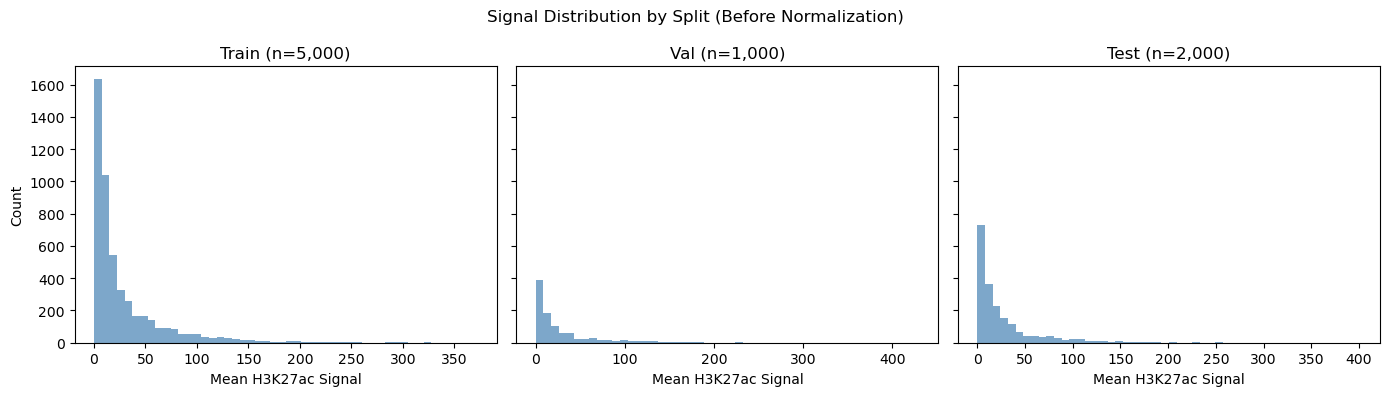

In [10]:
# ============================================================
# Step 3: Chromosome-aware data splits (matching lecture exactly)
# ============================================================
# Lecture: Train chr1-16, Val chr17-18, Test chr19-22+X
train_chroms = ['chr' + str(i) for i in range(1, 17)]
val_chroms   = ['chr17', 'chr18']
test_chroms  = ['chr' + str(i) for i in range(19, 23)] + ['chrX']

train_df = peaks[peaks.chrom.isin(train_chroms)].copy()
val_df   = peaks[peaks.chrom.isin(val_chroms)].copy()
test_df  = peaks[peaks.chrom.isin(test_chroms)].copy()

print(f'Full dataset -- Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

# Apply QUICK_MODE subsetting if enabled (random sample within each split)
if QUICK_MODE:
    if MAX_TRAIN and len(train_df) > MAX_TRAIN:
        train_df = train_df.sample(n=MAX_TRAIN, random_state=999)
    if MAX_VAL and len(val_df) > MAX_VAL:
        val_df = val_df.sample(n=MAX_VAL, random_state=999)
    if MAX_TEST and len(test_df) > MAX_TEST:
        test_df = test_df.sample(n=MAX_TEST, random_state=999)
    print(f'After QUICK_MODE subsetting -- Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

# Visualize signal distributions across splits
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, (name, df) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    ax.hist(df.mean_signal, bins=50, alpha=0.7, color='steelblue')
    ax.set_title(f'{name} (n={len(df):,})')
    ax.set_xlabel('Mean H3K27ac Signal')
axes[0].set_ylabel('Count')
plt.suptitle('Signal Distribution by Split (Before Normalization)')
plt.tight_layout()
plt.show()


## Steps 4–5 — Tokenization & Preprocessing

> *Lecture slide (Step 4): “Tokenization = how we discretize sequence for the model.”*
> *Lecture slide (Step 5): “Preprocessing must match the biological question*
> *AND the model’s pretraining assumptions.”*

### Tokenization Strategy

| Model | Tokenization | Rationale |
|-------|-------------|-----------|
| **Nucleotide Transformer** | Native learned tokenizer | “We do not change the tokenizer of a pre-trained FM lightly: it breaks pretraining” |
| **CNN Baseline** | One-hot encoding (A,C,G,T) | Standard for CNNs; base-level resolution for motif detection |

### Preprocessing

- **Signal normalization:** `log1p` transform to reduce right-skew in H3K27ac signal
  — *Lecture: “Log-transform or z-score normalize if needed”*
- **Sequence padding:** Pad/truncate to model’s expected input length
- **Reverse-complement augmentation:** Not applied here (H3K27ac is strand-agnostic,
  and NT was pre-trained on both strands). Discussed as optional extension.


In [11]:
# ============================================================
# Step 5: Log-transform signal for better regression targets
# ============================================================
# Lecture: "Log-transform or z-score normalize if needed"
# log1p reduces right-skew in H3K27ac signal; makes MSE loss more stable

for df in [train_df, val_df, test_df]:
    df['log_signal'] = np.log1p(df['mean_signal'].values)

print('Signal stats after log1p transform:')
print(f'  Train -- mean: {train_df.log_signal.mean():.2f}, std: {train_df.log_signal.std():.2f}')
print(f'  Val   -- mean: {val_df.log_signal.mean():.2f}, std: {val_df.log_signal.std():.2f}')
print(f'  Test  -- mean: {test_df.log_signal.mean():.2f}, std: {test_df.log_signal.std():.2f}')

# ============================================================
# Step 4: Dataset classes with appropriate tokenization
# ============================================================

# Load NT tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'\nNT tokenizer vocabulary size: {tokenizer.vocab_size:,}')

class NTEnhancerDataset(Dataset):
    """Dataset for Nucleotide Transformer: tokenized input + log-signal label."""
    def __init__(self, df):
        self.seqs = df.sequence.values
        self.labels = df.log_signal.values

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.seqs[idx],
            return_tensors='pt',
            truncation=True,
            padding='max_length',
            max_length=NT_MAX_LENGTH,
        )
        return {
            'input_ids': enc.input_ids.squeeze(0),
            'attention_mask': enc.attention_mask.squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float32),
        }


class CNNEnhancerDataset(Dataset):
    """Dataset for CNN baseline: one-hot encoded input + log-signal label."""
    def __init__(self, df, seq_len=1000):
        self.seqs = df.sequence.values
        self.labels = df.log_signal.values
        self.seq_len = seq_len

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        return {
            'sequence': torch.tensor(one_hot_encode(self.seqs[idx], self.seq_len)),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float32),
        }


Signal stats after log1p transform:
  Train -- mean: 2.75, std: 1.15
  Val   -- mean: 2.75, std: 1.17
  Test  -- mean: 2.72, std: 1.16

NT tokenizer vocabulary size: 4,107


In [12]:
# Create DataLoaders for both model types

# NT datasets
train_ds_nt = NTEnhancerDataset(train_df)
val_ds_nt   = NTEnhancerDataset(val_df)
test_ds_nt  = NTEnhancerDataset(test_df)

train_loader_nt = DataLoader(train_ds_nt, batch_size=BATCH_SIZE, shuffle=True)
val_loader_nt   = DataLoader(val_ds_nt,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_nt  = DataLoader(test_ds_nt,  batch_size=BATCH_SIZE, shuffle=False)

# CNN datasets
train_ds_cnn = CNNEnhancerDataset(train_df)
val_ds_cnn   = CNNEnhancerDataset(val_df)
test_ds_cnn  = CNNEnhancerDataset(test_df)

train_loader_cnn = DataLoader(train_ds_cnn, batch_size=BATCH_SIZE, shuffle=True)
val_loader_cnn   = DataLoader(val_ds_cnn,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_cnn  = DataLoader(test_ds_cnn,  batch_size=BATCH_SIZE, shuffle=False)

print(f'NT DataLoaders  -- Train: {len(train_loader_nt)} batches | Val: {len(val_loader_nt)} | Test: {len(test_loader_nt)}')
print(f'CNN DataLoaders -- Train: {len(train_loader_cnn)} batches | Val: {len(val_loader_cnn)} | Test: {len(test_loader_cnn)}')


NT DataLoaders  -- Train: 157 batches | Val: 32 | Test: 63
CNN DataLoaders -- Train: 157 batches | Val: 32 | Test: 63


## Step 6 — Experimental Setup

> *Lecture slide: “Make decisions explicit.”*

### Experiment Design

| Decision | Choice | Justification |
|----------|--------|---------------|
| **Input → Output** | 1 kb DNA sequence → scalar log(H3K27ac + 1) | Matches lecture running example |
| **Loss function** | MSE (Mean Squared Error) | Standard for regression; penalizes large errors. *Alternative: Huber loss for outlier robustness.* |
| **Primary metrics** | Pearson r, Spearman ρ | Correlation between predicted and actual signal |
| **Secondary metrics** | RMSE, R² | Error magnitude and variance explained |
| **Validation strategy** | Chromosome-aware splits + early stopping on val Pearson r | Prevents leakage and overfitting |

> *Lecture: “Avoid reporting only a single global metric without uncertainty.”*
> We will report **per-chromosome breakdowns** in Step 8.


In [14]:
# ============================================================
# Step 6: Training and evaluation utilities
# ============================================================
# Lecture: "Gradient clipping, weight decay, dropout in head"
# Lecture: "Early stopping on biologically meaningful metric"

def train_one_epoch(model, loader, optimizer, loss_fn, model_type='gfm'):
    """Train for one epoch. Returns average loss."""
    model.train()
    total_loss = 0
    for batch in tqdm(loader, desc='Training', leave=False):
        optimizer.zero_grad()
        labels = batch['labels'].to(device)

        if model_type == 'gfm':
            preds = model(batch['input_ids'].to(device),
                          batch['attention_mask'].to(device))
        else:  # cnn
            preds = model(batch['sequence'].to(device))

        loss = loss_fn(preds, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, model_type='gfm'):
    """Evaluate model. Returns dict with Pearson, Spearman, RMSE, R^2.

    Lecture: "Pearson, Spearman, RMSE... Report per-track, per-chromosome"
    """
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            if model_type == 'gfm':
                preds = model(batch['input_ids'].to(device),
                              batch['attention_mask'].to(device))
            else:
                preds = model(batch['sequence'].to(device))
            all_preds.append(preds.cpu())
            all_labels.append(batch['labels'])

    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()

    return {
        'pearson':  float(pearsonr(labels, preds)[0]),
        'spearman': float(spearmanr(labels, preds).correlation),
        'rmse':     float(np.sqrt(mean_squared_error(labels, preds))),
        'r2':       float(r2_score(labels, preds)),
    }


def train_model(model, train_loader, val_loader, optimizer, loss_fn,
                model_type='gfm', num_epochs=NUM_EPOCHS, patience=PATIENCE,
                save_path='best_model.pt'):
    """Full training loop with early stopping on validation Pearson r.

    Lecture: "Early stopping on biologically meaningful metric"
    Lecture: "Hyperparameter search on validation only"
    """
    best_val_pearson = -float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_pearson': [], 'val_spearman': []}

    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, model_type)
        val_metrics = evaluate(model, val_loader, model_type)

        history['train_loss'].append(train_loss)
        history['val_pearson'].append(val_metrics['pearson'])
        history['val_spearman'].append(val_metrics['spearman'])

        print(f'  Epoch {epoch+1}/{num_epochs} -- Loss: {train_loss:.4f} | '
              f'Val Pearson: {val_metrics["pearson"]:.4f} | '
              f'Val Spearman: {val_metrics["spearman"]:.4f}')

        # Early stopping on validation Pearson
        if val_metrics['pearson'] > best_val_pearson:
            best_val_pearson = val_metrics['pearson']
            torch.save(model.state_dict(), save_path)
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    # Load best model
    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    return model, history


## Step 7 — Fine-Tuning

> *Lecture slide: “Best practices: Backbone LR ~1e-5 to 1e-6 (conservative), Head LR ~1e-3 to 1e-4”*

### Stage 1: Frozen Backbone

Freeze **all** backbone parameters. Only the regression head trains.
This tells us: **how useful are the pre-trained representations as-is?**

> *Lecture: “Freeze backbone, train prediction head → diagnostic baseline”*


In [16]:
# ============================================================
# Step 7, Stage 1: Frozen backbone -- train head only
# ============================================================
# Lecture: "Freeze backbone, train prediction head -> diagnostic baseline"

print('=' * 60)
print('STAGE 1: Frozen Backbone')
print('=' * 60)

gfm_model = GFMRegressor(MODEL_NAME, freeze_backbone=True).to(device)

trainable = sum(p.numel() for p in gfm_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in gfm_model.parameters())
print(f'Trainable: {trainable:,} / {total_params:,} parameters ({100*trainable/total_params:.2f}%)')

# Only head parameters have gradients
optimizer_s1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, gfm_model.parameters()),
    lr=1e-3, weight_decay=0.01
)
loss_fn = nn.MSELoss()

gfm_model, history_s1 = train_model(
    gfm_model, train_loader_nt, val_loader_nt, optimizer_s1, loss_fn,
    model_type='gfm', save_path='best_frozen.pt'
)

frozen_test = evaluate(gfm_model, test_loader_nt, model_type='gfm')
print(f'\nStage 1 (Frozen) Test Results:')
for k, v in frozen_test.items():
    print(f'  {k}: {v:.4f}')


STAGE 1: Frozen Backbone


Some weights of EsmModel were not initialized from the model checkpoint at InstaDeepAI/nucleotide-transformer-500m-human-ref and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Trainable: 164,097 / 480,602,338 parameters (0.03%)


  Epoch 1/5 -- Loss: 1.3239 | Val Pearson: 0.4282 | Val Spearman: 0.4155


  Epoch 2/5 -- Loss: 1.1557 | Val Pearson: 0.4452 | Val Spearman: 0.4304


  Epoch 3/5 -- Loss: 1.0809 | Val Pearson: 0.4489 | Val Spearman: 0.4315


  Epoch 4/5 -- Loss: 1.0797 | Val Pearson: 0.4497 | Val Spearman: 0.4295


  Epoch 5/5 -- Loss: 1.0907 | Val Pearson: 0.4506 | Val Spearman: 0.4275

Stage 1 (Frozen) Test Results:
  pearson: 0.4712
  spearman: 0.4553
  rmse: 1.0318
  r2: 0.2100


### Stage 2: Partial Unfreeze (Top Layers)

> *Lecture: “Unfreeze top N layers (e.g., 2–4), train with low LR on backbone”*

We unfreeze the top 2 transformer layers and use **differential learning rates**:
- **Head:** 1e-3 (learn the task-specific mapping)
- **Unfrozen backbone layers:** 1e-5 (gently adapt representations)

> *“This reduces catastrophic forgetting and lets you pay for complexity as needed.”*


In [ ]:
# ============================================================
# Step 7, Stage 2: Unfreeze top transformer layers
# ============================================================
# Lecture: "Unfreeze top N layers (e.g., 2-4), train with low LR on backbone"

print('=' * 60)
print(f'STAGE 2: Unfreezing Top {NUM_UNFREEZE_LAYERS} Layers')
print('=' * 60)

# Start from best frozen model
gfm_model.load_state_dict(torch.load('best_frozen.pt', map_location=device, weights_only=True))

# Unfreeze top N transformer layers
encoder_layers = gfm_model.backbone.encoder.layer
num_layers = len(encoder_layers)
print(f'Backbone has {num_layers} transformer layers; unfreezing top {NUM_UNFREEZE_LAYERS}')

for layer in encoder_layers[-NUM_UNFREEZE_LAYERS:]:
    for p in layer.parameters():
        p.requires_grad = True

trainable = sum(p.numel() for p in gfm_model.parameters() if p.requires_grad)
print(f'Trainable: {trainable:,} / {total_params:,} parameters ({100*trainable/total_params:.2f}%)')

# Differential learning rates
# Lecture: "Backbone: ~1e-5 to 1e-6 (conservative), Head: ~1e-3 to 1e-4"
unfrozen_backbone_params = []
for layer in encoder_layers[-NUM_UNFREEZE_LAYERS:]:
    unfrozen_backbone_params.extend(layer.parameters())

optimizer_s2 = torch.optim.AdamW([
    {'params': gfm_model.head.parameters(), 'lr': 1e-3},
    {'params': unfrozen_backbone_params, 'lr': 1e-5},
], weight_decay=0.01)

gfm_model, history_s2 = train_model(
    gfm_model, train_loader_nt, val_loader_nt, optimizer_s2, loss_fn,
    model_type='gfm', save_path='best_partial.pt'
)

partial_test = evaluate(gfm_model, test_loader_nt, model_type='gfm')
print(f'\nStage 2 (Partial FT) Test Results:')
for k, v in partial_test.items():
    print(f'  {k}: {v:.4f}')


### CNN Baseline (No Pre-Training)

> *Lecture: “Baseline: Small CNN trained from scratch on the same windows.”*

This comparison tells us whether the foundation model’s pre-trained
representations provide genuine benefit over learning from scratch.


In [17]:
# ============================================================
# Step 7: Train CNN Baseline from scratch
# ============================================================
# Lecture: "Always compare to a reasonable baseline, not just other FMs."

print('=' * 60)
print('CNN BASELINE: Training from scratch')
print('=' * 60)

cnn_model = CNNBaseline().to(device)
trainable_cnn = sum(p.numel() for p in cnn_model.parameters())
print(f'CNN parameters: {trainable_cnn:,} (all trainable)')

optimizer_cnn = torch.optim.AdamW(cnn_model.parameters(), lr=1e-3, weight_decay=0.01)

cnn_model, history_cnn = train_model(
    cnn_model, train_loader_cnn, val_loader_cnn, optimizer_cnn, loss_fn,
    model_type='cnn', save_path='best_cnn.pt'
)

cnn_test = evaluate(cnn_model, test_loader_cnn, model_type='cnn')
print(f'\nCNN Baseline Test Results:')
for k, v in cnn_test.items():
    print(f'  {k}: {v:.4f}')


CNN BASELINE: Training from scratch
CNN parameters: 104,897 (all trainable)


  Epoch 1/5 -- Loss: 1.5105 | Val Pearson: 0.4138 | Val Spearman: 0.4000


  Epoch 2/5 -- Loss: 1.1643 | Val Pearson: 0.4163 | Val Spearman: 0.4059


  Epoch 3/5 -- Loss: 1.1518 | Val Pearson: 0.3993 | Val Spearman: 0.3876


  Epoch 4/5 -- Loss: 1.0739 | Val Pearson: 0.4388 | Val Spearman: 0.4154


  Epoch 5/5 -- Loss: 1.0459 | Val Pearson: 0.4346 | Val Spearman: 0.4039

CNN Baseline Test Results:
  pearson: 0.4502
  spearman: 0.4300
  rmse: 1.0420
  r2: 0.1943


## Step 8 — Evaluation & Interpretation

> *Lecture slide: “Beyond scalar performance... Attribution maps, motif recovery,*
> *per-chromosome generalization.”*

### Evaluation Plan

1. **Model comparison table** — GFM frozen vs partial FT vs CNN baseline
2. **Per-chromosome metrics** — detect uneven performance across genomic regions
3. **Saliency / attribution maps** — identify sequence features driving predictions


MODEL COMPARISON (Test Set)
              pearson  spearman   rmse     r2
GFM Frozen     0.4712    0.4553 1.0318 0.2100
CNN Baseline   0.4502    0.4300 1.0420 0.1943



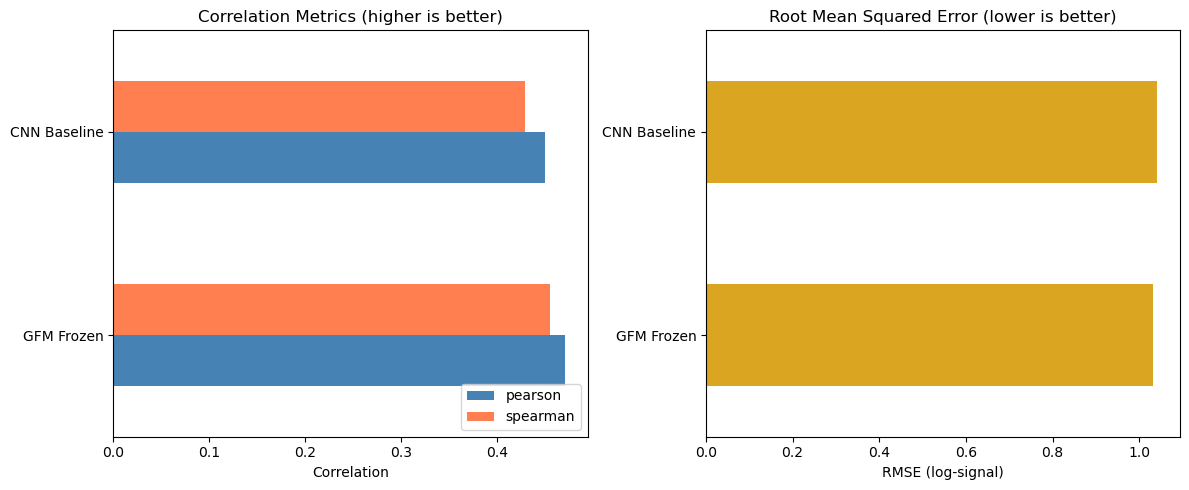

In [19]:
# ============================================================
# Step 8: Model comparison
# ============================================================
# Lecture: "Always compare to a reasonable baseline"

results = pd.DataFrame({
    'GFM Frozen': frozen_test,
    #'GFM Partial FT': partial_test,
    'CNN Baseline': cnn_test,
}).T

print('=' * 60)
print('MODEL COMPARISON (Test Set)')
print('=' * 60)
print(results.to_string(float_format='{:.4f}'.format))
print()

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pearson & Spearman
results[['pearson', 'spearman']].plot.barh(ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_xlabel('Correlation')
axes[0].set_title('Correlation Metrics (higher is better)')
axes[0].legend(loc='lower right')

# RMSE
results[['rmse']].plot.barh(ax=axes[1], color='goldenrod', legend=False)
axes[1].set_xlabel('RMSE (log-signal)')
axes[1].set_title('Root Mean Squared Error (lower is better)')

plt.tight_layout()
plt.show()


Some weights of EsmModel were not initialized from the model checkpoint at InstaDeepAI/nucleotide-transformer-500m-human-ref and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


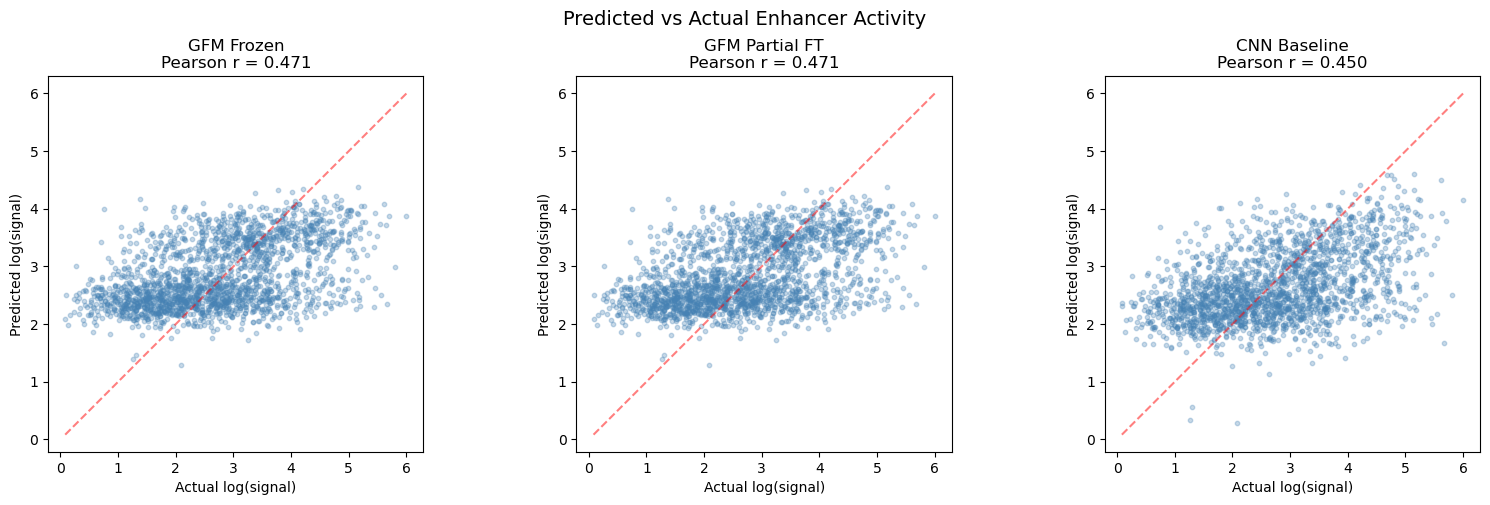

In [20]:
# ============================================================
# Step 8: Predicted vs Actual scatter plots
# ============================================================

def get_predictions(model, loader, model_type='gfm'):
    """Get all predictions and labels from a loader."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            if model_type == 'gfm':
                preds = model(batch['input_ids'].to(device),
                              batch['attention_mask'].to(device))
            else:
                preds = model(batch['sequence'].to(device))
            all_preds.append(preds.cpu())
            all_labels.append(batch['labels'])
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models_info = [
    ('GFM Frozen', gfm_model, test_loader_nt, 'gfm'),  # Note: gfm_model currently holds partial FT weights
]

# Reload frozen weights for scatter plot
gfm_frozen_model = GFMRegressor(MODEL_NAME, freeze_backbone=True).to(device)
gfm_frozen_model.load_state_dict(torch.load('best_frozen.pt', map_location=device, weights_only=True))

for ax, (title, mdl, loader, mtype) in zip(axes, [
    ('GFM Frozen', gfm_frozen_model, test_loader_nt, 'gfm'),
    ('GFM Partial FT', gfm_model, test_loader_nt, 'gfm'),
    ('CNN Baseline', cnn_model, test_loader_cnn, 'cnn'),
]):
    preds, labels = get_predictions(mdl, loader, mtype)
    ax.scatter(labels, preds, alpha=0.3, s=10, color='steelblue')
    # Identity line
    lims = [min(labels.min(), preds.min()), max(labels.max(), preds.max())]
    ax.plot(lims, lims, 'r--', alpha=0.5)
    ax.set_xlabel('Actual log(signal)')
    ax.set_ylabel('Predicted log(signal)')
    ax.set_title(f'{title}\nPearson r = {pearsonr(labels, preds)[0]:.3f}')
    ax.set_aspect('equal', adjustable='box')

plt.suptitle('Predicted vs Actual Enhancer Activity', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# Step 8: Per-chromosome evaluation (using TRAINED model)
# ============================================================
# Lecture: "Report per-track, per-chromosome"
#
# IMPORTANT: We use the already-trained gfm_model (partial FT),
# NOT a newly initialized model! (This was a bug in the v1 notebook.)

print('Per-Chromosome Test Metrics (GFM Partial FT)')
print('-' * 50)

chrom_results = {}
for chrom in test_chroms:
    chrom_subset = test_df[test_df.chrom == chrom]
    if len(chrom_subset) < 10:
        print(f'  {chrom}: skipped (n={len(chrom_subset)}, need >= 10)')
        continue

    chrom_loader = DataLoader(
        NTEnhancerDataset(chrom_subset),
        batch_size=BATCH_SIZE, shuffle=False
    )
    metrics = evaluate(gfm_model, chrom_loader, model_type='gfm')
    chrom_results[chrom] = metrics
    print(f'  {chrom} (n={len(chrom_subset):,}): '
          f'Pearson={metrics["pearson"]:.3f}, '
          f'Spearman={metrics["spearman"]:.3f}, '
          f'RMSE={metrics["rmse"]:.3f}')

# Visualize per-chromosome performance
if chrom_results:
    chrom_metrics_df = pd.DataFrame(chrom_results).T
    fig, ax = plt.subplots(figsize=(10, 5))
    chrom_metrics_df[['pearson', 'spearman']].plot.bar(ax=ax, color=['steelblue', 'coral'])
    ax.set_ylabel('Correlation')
    ax.set_title('Per-Chromosome Performance (GFM Partial FT)')
    ax.set_xlabel('Chromosome')
    ax.axhline(y=partial_test['pearson'], color='steelblue', linestyle='--',
               alpha=0.5, label='Overall Pearson')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


### Saliency / Attribution Analysis

> *Lecture: “Highlight sequence regions that drive predictions...*
> *Do high-saliency regions overlap known enhancer motifs?”*

We use **Integrated Gradients** (Sundararajan et al., 2017) on the **CNN baseline**
to identify which positions in the input sequence most influence predicted activity.

The CNN is used here because its one-hot input makes gradient attribution
straightforward and biologically interpretable (each position maps directly to a nucleotide).


In [ ]:
# ============================================================
# Step 8: Saliency analysis using Integrated Gradients on CNN
# ============================================================
# Lecture: "Visualize saliency maps across windows"
# Lecture: "Do high-saliency regions overlap known enhancer motifs (e.g., AP-1, GATA)?"

cnn_model.eval()

# Select a high-activity test example for clear visualization
high_idx = test_df.log_signal.values.argmax()
sample_row = test_df.iloc[high_idx]
sample_seq = sample_row.sequence

sample_encoded = torch.tensor(
    one_hot_encode(sample_seq), dtype=torch.float32
).unsqueeze(0).to(device)
sample_encoded.requires_grad_(True)

# Compute Integrated Gradients (baseline = zero tensor = "no sequence")
ig = IntegratedGradients(cnn_model)
attributions = ig.attribute(sample_encoded, n_steps=50)

# Per-position importance: sum absolute attribution over ACGT channels
importance = attributions.squeeze().cpu().detach().numpy()
pos_importance = np.abs(importance).sum(axis=0)

# Smooth for visualization (20bp rolling window)
window = 20
smoothed = np.convolve(pos_importance, np.ones(window)/window, mode='same')

# Plot
fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={'height_ratios': [2, 1]})

# Attribution scores
axes[0].fill_between(range(len(smoothed)), smoothed, alpha=0.7, color='steelblue')
axes[0].set_ylabel('Attribution (smoothed)')

pred_val = cnn_model(sample_encoded).item()
axes[0].set_title(
    f'Integrated Gradients Attribution (CNN Baseline)\n'
    f'{sample_row.chrom}:{sample_row.win_start}-{sample_row.win_end} | '
    f'Predicted: {pred_val:.2f} | Actual: {sample_row.log_signal:.2f}'
)
axes[0].set_xlim(0, len(smoothed))

# GC content profile for comparison
gc = np.array([1 if b in 'GC' else 0 for b in sample_seq[:1000]])
gc_smooth = np.convolve(gc, np.ones(window)/window, mode='same')
axes[1].fill_between(range(len(gc_smooth)), gc_smooth, alpha=0.5, color='coral')
axes[1].set_ylabel('GC Content')
axes[1].set_xlabel('Position (bp)')
axes[1].set_xlim(0, len(gc_smooth))
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Report top-attributed regions
top_positions = np.argsort(pos_importance)[-10:][::-1]
print('Top 10 highest-attribution positions:')
for pos in top_positions:
    context = sample_seq[max(0, pos-5):pos+6]
    print(f'  Position {pos}: ...{context}... (attribution: {pos_importance[pos]:.4f})')

print()
print('> Check: Do these regions overlap known K562 enhancer motifs (AP-1, GATA, etc.)?')
print('> This is where biological domain knowledge validates the model.')
print('> Lecture: "A model that predicts well but cannot be connected to biology')
print('>          is less useful for discovery."')


### Training Curves

Visualize convergence behavior for all three training runs. Look for:
- **Overfitting:** training loss drops but validation metric plateaus or worsens
- **Underfitting:** both metrics plateau at low performance
- **Benefit of unfreezing:** does Stage 2 improve over Stage 1?


In [ ]:
# ============================================================
# Training curves comparison
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (title, hist) in zip(axes, [
    ('GFM Stage 1 (Frozen)', history_s1),
    ('GFM Stage 2 (Partial FT)', history_s2),
    ('CNN Baseline', history_cnn),
]):
    epochs = range(1, len(hist['train_loss']) + 1)
    ax2 = ax.twinx()
    ax.plot(epochs, hist['train_loss'], 'b-o', markersize=4, label='Train Loss')
    ax2.plot(epochs, hist['val_pearson'], 'r-s', markersize=4, label='Val Pearson')
    ax2.plot(epochs, hist['val_spearman'], 'g-^', markersize=4, label='Val Spearman')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss', color='b')
    ax2.set_ylabel('Correlation', color='r')
    ax.set_title(title)
    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=8)

plt.tight_layout()
plt.show()


## Summary & Next Steps

### What We Implemented (Full Lecture Workflow)

| Step | Lecture Concept | Implementation |
|:---:|---|---|
| 0 | Biological question | 1kb DNA → log(H3K27ac) regression |
| 1 | Model + baseline | Nucleotide Transformer + CNN from scratch |
| 2 | Fine-tuning strategy | Staged: frozen → partial unfreeze |
| 3 | Data splits | Chromosome-aware (train 1–16, val 17–18, test 19–22+X) |
| 4 | Tokenization | NT native tokenizer + one-hot for CNN |
| 5 | Preprocessing | Log-transform, length normalization |
| 6 | Metrics | Pearson, Spearman, RMSE, R² |
| 7 | Fine-tuning | Stage 1 + Stage 2 + CNN baseline |
| 8 | Evaluation | Per-chromosome metrics, model comparison, saliency maps |

### Key Takeaways

1. **Most critical decisions happen outside the architecture** — data splits, preprocessing, and evaluation design matter more than model choice
2. **Staged fine-tuning** protects pre-trained knowledge while adapting to the task
3. **Baselines are essential** — if a simple CNN matches the GFM, pre-training may not help for this task
4. **Per-chromosome evaluation** reveals whether performance is robust or driven by specific genomic regions
5. **Attribution analysis** connects predictions back to biology

> *Lecture: “A systematic workflow plus reflective iteration beats trial-and-error hyperparameter fishing.”*

### Extensions (For Further Exploration)

- **Reverse-complement augmentation** — train on both strands for strand-agnostic tasks
- **Full fine-tuning** — unfreeze all layers with very low backbone LR
- **Cross-cell-type transfer** — train on K562, test on another myeloid cell type
- **Homology-aware splits** — filter out similar sequences across train/test chromosomes
- **In silico mutagenesis** — mutate high-saliency positions and observe prediction changes
